In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!pip -q install timm umap-learn thop

**Imports + Config**

In [2]:
import os
import copy
import time
import random
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import datasets, transforms, models

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, auc, silhouette_score
)
from sklearn.preprocessing import label_binarize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap

from thop import profile

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DATA_ROOT = "/kaggle/input/datasets/diptadasopu/processed-rice-varieties-of-bangladesh/PRBD Microscopic Image of Different Processed Rice/Original_Images"
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

TRAIN_RATIO = 0.8
VAL_RATIO_WITHIN_TRAIN = 0.1

SSL_EPOCHS = 50
LINEAR_EPOCHS = 20
FINETUNE_EPOCHS = 20

LR_SSL = 1e-3
LR_LINEAR = 1e-3
LR_FINETUNE = 1e-4
WEIGHT_DECAY = 1e-4

TEMPERATURE = 0.5
USE_MIXED_PRECISION = True

BACKBONE_NAME = "resnet50"   
PROJECTION_DIM = 128

print("Config loaded successfully.")
print("DATA_ROOT:", DATA_ROOT)

2026-04-03 09:41:21.126937: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775209281.347951      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775209281.409266      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775209281.896647      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775209281.896686      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775209281.896689      55 computation_placer.cc:177] computation placer alr

DEVICE: cuda
Config loaded successfully.
DATA_ROOT: /kaggle/input/datasets/diptadasopu/processed-rice-varieties-of-bangladesh/PRBD Microscopic Image of Different Processed Rice/Original_Images


**Load dataset and split**

In [3]:
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

full_dataset = datasets.ImageFolder(DATA_ROOT, transform=eval_transform)
class_names = full_dataset.classes
NUM_CLASSES = len(class_names)

print("Classes:", class_names)
print("NUM_CLASSES:", NUM_CLASSES)
print("Total images:", len(full_dataset))

n_total = len(full_dataset)
n_train_total = int(TRAIN_RATIO * n_total)
n_test = n_total - n_train_total

n_val = int(VAL_RATIO_WITHIN_TRAIN * n_train_total)
n_train = n_train_total - n_val

generator = torch.Generator().manual_seed(SEED)

train_subset, val_subset, test_subset = random_split(
    full_dataset,
    [n_train, n_val, n_test],
    generator=generator
)

print(f"Train: {len(train_subset)}")
print(f"Val:   {len(val_subset)}")
print(f"Test:  {len(test_subset)}")

Classes: ['Aush', 'BR-28', 'BR-29', 'Beroi', 'Chinigura', 'Ghee Bhog', 'Katari Najir', 'Katari Siddho', 'Miniket', 'Swarna']
NUM_CLASSES: 10
Total images: 2000
Train: 1440
Val:   160
Test:  400


**Dataset wrappers + augmentation recipe**

In [5]:
class TransformSubset(Dataset):
    def __init__(self, subset, full_dataset, transform=None):
        self.subset = subset
        self.full_dataset = full_dataset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        real_idx = self.subset.indices[idx]
        path, target = self.full_dataset.samples[real_idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, target

simclr_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
])

class SimCLRDataset(Dataset):
    def __init__(self, subset, full_dataset, transform):
        self.subset = subset
        self.full_dataset = full_dataset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        real_idx = self.subset.indices[idx]
        path, target = self.full_dataset.samples[real_idx]
        img = Image.open(path).convert("RGB")
        x1 = self.transform(img)
        x2 = self.transform(img)
        return x1, x2, target


train_ds_ssl = SimCLRDataset(train_subset, full_dataset, simclr_transform)

train_ds_eval = TransformSubset(train_subset, full_dataset, eval_transform)
val_ds_eval   = TransformSubset(val_subset, full_dataset, eval_transform)
test_ds_eval  = TransformSubset(test_subset, full_dataset, eval_transform)

ssl_loader = DataLoader(train_ds_ssl, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
train_loader_eval = DataLoader(train_ds_eval, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader_eval   = DataLoader(val_ds_eval, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader_eval  = DataLoader(test_ds_eval, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print("DataLoaders ready.")

DataLoaders ready.


**Visual check**

Sample shape: torch.Size([3, 224, 224])
Sample class: Katari Siddho


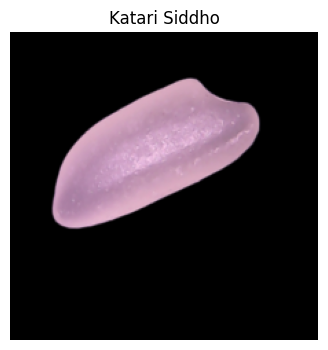

In [6]:
sample_img, sample_label = train_ds_eval[0]
print("Sample shape:", sample_img.shape)
print("Sample class:", class_names[sample_label])

plt.figure(figsize=(4,4))
plt.imshow(sample_img.permute(1,2,0))
plt.title(class_names[sample_label])
plt.axis("off")
plt.show()

**SimCLR model and loss**

In [8]:
class SimCLR(nn.Module):
    def __init__(self, backbone_name="resnet18", projection_dim=128):
        super().__init__()

        if backbone_name == "resnet18":
            backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
            feat_dim = backbone.fc.in_features
            self.encoder = nn.Sequential(*list(backbone.children())[:-1])

        elif backbone_name == "resnet50":
            backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
            feat_dim = backbone.fc.in_features
            self.encoder = nn.Sequential(*list(backbone.children())[:-1])

        else:
            raise ValueError("Unsupported backbone_name")

        self.feat_dim = feat_dim

        self.projector = nn.Sequential(
            nn.Linear(feat_dim, 512),
            nn.ReLU(),
            nn.Linear(512, projection_dim)
        )

    def forward(self, x):
        h = self.encoder(x).flatten(1)
        z = self.projector(h)
        z = F.normalize(z, dim=1)
        return h, z


def nt_xent_loss(z1, z2, temperature=0.5):
    batch_size = z1.size(0)

    z = torch.cat([z1, z2], dim=0)
    sim = F.cosine_similarity(z.unsqueeze(1), z.unsqueeze(0), dim=2)
    sim = sim / temperature

    mask = torch.eye(2 * batch_size, device=z.device).bool()
    sim = sim.masked_fill(mask, -1e9)

    positive_indices = torch.cat([
        torch.arange(batch_size, 2 * batch_size),
        torch.arange(0, batch_size)
    ]).to(z.device)

    loss = F.cross_entropy(sim, positive_indices)
    return loss

**SimCLR SSL pretraining**

In [9]:
simclr_model = SimCLR(
    backbone_name=BACKBONE_NAME,
    projection_dim=PROJECTION_DIM
).to(DEVICE)

optimizer = torch.optim.AdamW(simclr_model.parameters(), lr=LR_SSL, weight_decay=WEIGHT_DECAY)
scaler = torch.cuda.amp.GradScaler(enabled=USE_MIXED_PRECISION)

ssl_history = {"loss": []}

start_ssl = time.time()

for epoch in range(SSL_EPOCHS):
    simclr_model.train()
    running_loss = 0.0

    for x1, x2, _ in ssl_loader:
        x1 = x1.to(DEVICE)
        x2 = x2.to(DEVICE)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):
            _, z1 = simclr_model(x1)
            _, z2 = simclr_model(x2)
            loss = nt_xent_loss(z1, z2, temperature=TEMPERATURE)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * x1.size(0)

    epoch_loss = running_loss / len(ssl_loader.dataset)
    ssl_history["loss"].append(epoch_loss)

    print(f"SSL Epoch [{epoch+1}/{SSL_EPOCHS}] Loss: {epoch_loss:.4f}")

ssl_train_time = time.time() - start_ssl
print(f"SimCLR SSL pretraining finished in {ssl_train_time:.2f} sec")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 195MB/s]
/tmp/ipykernel_55/2992785953.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_MIXED_PRECISION)
/tmp/ipykernel_55/2992785953.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):


SSL Epoch [1/50] Loss: 2.9601
SSL Epoch [2/50] Loss: 2.6980
SSL Epoch [3/50] Loss: 2.5794
SSL Epoch [4/50] Loss: 2.5249
SSL Epoch [5/50] Loss: 2.4882
SSL Epoch [6/50] Loss: 2.4736
SSL Epoch [7/50] Loss: 2.4566
SSL Epoch [8/50] Loss: 2.4481
SSL Epoch [9/50] Loss: 2.4127
SSL Epoch [10/50] Loss: 2.4105
SSL Epoch [11/50] Loss: 2.3974
SSL Epoch [12/50] Loss: 2.3879
SSL Epoch [13/50] Loss: 2.3787
SSL Epoch [14/50] Loss: 2.3852
SSL Epoch [15/50] Loss: 2.3736
SSL Epoch [16/50] Loss: 2.3762
SSL Epoch [17/50] Loss: 2.3653
SSL Epoch [18/50] Loss: 2.3621
SSL Epoch [19/50] Loss: 2.3746
SSL Epoch [20/50] Loss: 2.3843
SSL Epoch [21/50] Loss: 2.3676
SSL Epoch [22/50] Loss: 2.3476
SSL Epoch [23/50] Loss: 2.3436
SSL Epoch [24/50] Loss: 2.3368
SSL Epoch [25/50] Loss: 2.3439
SSL Epoch [26/50] Loss: 2.3347
SSL Epoch [27/50] Loss: 2.3355
SSL Epoch [28/50] Loss: 2.3371
SSL Epoch [29/50] Loss: 2.3335
SSL Epoch [30/50] Loss: 2.3324
SSL Epoch [31/50] Loss: 2.3288
SSL Epoch [32/50] Loss: 2.3447
SSL Epoch [33/50]

**Save frozen encoder**

In [10]:
torch.save(simclr_model.encoder.state_dict(), "/kaggle/working/simclr_frozen_encoder.pth")
print("Frozen encoder saved: /kaggle/working/simclr_frozen_encoder.pth")

Frozen encoder saved: /kaggle/working/simclr_frozen_encoder.pth


**Linear probe model**

In [12]:
class SimCLRLinearProbe(nn.Module):
    def __init__(self, ssl_model, backbone_name, num_classes):
        super().__init__()
        self.encoder = ssl_model.encoder

        for p in self.encoder.parameters():
            p.requires_grad = False

        if backbone_name == "resnet18":
            feat_dim = 512
        elif backbone_name == "resnet50":
            feat_dim = 2048
        else:
            raise ValueError("Unsupported backbone_name")

        self.fc = nn.Linear(feat_dim, num_classes)

    def forward(self, x):
        feat = self.encoder(x).flatten(1)
        return self.fc(feat)

linear_probe = SimCLRLinearProbe(simclr_model, BACKBONE_NAME, NUM_CLASSES).to(DEVICE)
print("Linear probe ready.")

Linear probe ready.


**Training function for torch models**

In [14]:
def train_torch_classifier(model, train_loader, val_loader, epochs=20, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scaler = torch.cuda.amp.GradScaler(enabled=USE_MIXED_PRECISION)

    best_val_acc = 0.0
    best_state = copy.deepcopy(model.state_dict())

    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    start = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):
                logits = model(imgs)
                loss = nn.CrossEntropyLoss()(logits, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * imgs.size(0)

        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        preds_all, labels_all = [], []

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

                with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):
                    logits = model(imgs)
                    loss = criterion(logits, labels)

                val_loss += loss.item() * imgs.size(0)
                preds = torch.argmax(logits, dim=1)

                preds_all.extend(preds.cpu().numpy())
                labels_all.extend(labels.cpu().numpy())

        val_loss /= len(val_loader.dataset)
        val_acc = accuracy_score(labels_all, preds_all)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    total_time = time.time() - start
    model.load_state_dict(best_state)
    return model, history, total_time

**Train linear probe**

In [15]:
linear_probe, linear_history, linear_train_time = train_torch_classifier(
    linear_probe,
    train_loader_eval,
    val_loader_eval,
    epochs=LINEAR_EPOCHS,
    lr=LR_LINEAR
)

print(f"Linear probe training finished in {linear_train_time:.2f} sec")

/tmp/ipykernel_55/2095318593.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_MIXED_PRECISION)
/tmp/ipykernel_55/2095318593.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):
/tmp/ipykernel_55/2095318593.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):


Epoch [1/20] Train Loss: 1.1361 | Val Loss: 0.7260 | Val Acc: 0.6813


/tmp/ipykernel_55/2095318593.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):
/tmp/ipykernel_55/2095318593.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):


Epoch [2/20] Train Loss: 0.7572 | Val Loss: 0.6185 | Val Acc: 0.7000


/tmp/ipykernel_55/2095318593.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):
/tmp/ipykernel_55/2095318593.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):


...

Epoch [18/20] Train Loss: 0.5063 | Val Loss: 0.4510 | Val Acc: 0.8250


/tmp/ipykernel_55/2095318593.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):
/tmp/ipykernel_55/2095318593.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):


Epoch [19/20] Train Loss: 0.5262 | Val Loss: 0.4322 | Val Acc: 0.8313


/tmp/ipykernel_55/2095318593.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):
/tmp/ipykernel_55/2095318593.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):


Epoch [20/20] Train Loss: 0.5228 | Val Loss: 0.4327 | Val Acc: 0.8313
Linear probe training finished in 182.68 sec


**Evaluation function**

In [16]:
def evaluate_torch_model(model, test_loader, class_names):
    model.eval()

    probs_all = []
    preds_all = []
    labels_all = []

    start = time.time()

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(DEVICE)
            logits = model(imgs)
            probs = F.softmax(logits, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)

            probs_all.extend(probs)
            preds_all.extend(preds)
            labels_all.extend(labels.numpy())

    test_time = time.time() - start

    labels_all = np.array(labels_all)
    preds_all = np.array(preds_all)
    probs_all = np.array(probs_all)

    acc = accuracy_score(labels_all, preds_all)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels_all, preds_all, average="weighted", zero_division=0
    )

    cm = confusion_matrix(labels_all, preds_all)

    per_class_acc = {}
    for i, cls in enumerate(class_names):
        row_sum = cm[i].sum()
        per_class_acc[cls] = cm[i, i] / row_sum if row_sum > 0 else 0.0

    y_true_bin = label_binarize(labels_all, classes=list(range(len(class_names))))
    try:
        roc_auc = roc_auc_score(y_true_bin, probs_all, multi_class="ovr", average="weighted")
    except Exception:
        roc_auc = None

    print("\n=== TEST RESULTS ===")
    print("Accuracy :", acc)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1-score :", f1)
    print("ROC-AUC  :", roc_auc)
    print("Test Time:", test_time)

    print("\n=== PER-CLASS ACCURACY ===")
    for k, v in per_class_acc.items():
        print(f"{k}: {v:.4f}")

    print("\n=== CONFUSION MATRIX ===")
    print(cm)

    print("\n=== CLASSIFICATION REPORT ===")
    print(classification_report(labels_all, preds_all, target_names=class_names, zero_division=0))

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
        "confusion_matrix": cm,
        "per_class_acc": per_class_acc,
        "test_time_sec": test_time,
        "probs": probs_all,
        "labels": labels_all,
        "preds": preds_all
    }

**Evaluate linear probe**

In [17]:
linear_results = evaluate_torch_model(linear_probe, test_loader_eval, class_names)


=== TEST RESULTS ===
Accuracy : 0.7875
Precision: 0.7884743772796164
Recall   : 0.7875
F1-score : 0.7850661833859608
ROC-AUC  : 0.9782604775633914
Test Time: 3.5426619052886963

=== PER-CLASS ACCURACY ===
Aush: 0.9500
BR-28: 0.5946
BR-29: 0.7778
Beroi: 0.9362
Chinigura: 0.9737
Ghee Bhog: 0.9024
Katari Najir: 0.5349
Katari Siddho: 0.6750
Miniket: 0.9091
Swarna: 0.6111

=== CONFUSION MATRIX ===
[[38  0  0  2  0  0  0  0  0  0]
 [ 0 22  0  0  0  0  0  7  3  5]
 [ 0  0 35  0  0  0  4  2  0  4]
 [ 3  0  0 44  0  0  0  0  0  0]
 [ 0  0  0  0 37  0  1  0  0  0]
 [ 0  0  1  0  0 37  3  0  0  0]
 [ 0  1  5  0  0 14 23  0  0  0]
 [ 0  7  1  0  2  0  0 27  0  3]
 [ 0  0  1  0  0  0  0  2 30  0]
 [ 0  5  0  0  0  0  1  8  0 22]]

=== CLASSIFICATION REPORT ===
               precision    recall  f1-score   support

         Aush       0.93      0.95      0.94        40
        BR-28       0.63      0.59      0.61        37
        BR-29       0.81      0.78      0.80        45
        Beroi       

**Feature extraction from frozen encoder**

In [18]:
def extract_features(encoder, loader, device):
    encoder.eval()
    feats = []
    labels_all = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            f = encoder(imgs).flatten(1)
            feats.append(f.cpu().numpy())
            labels_all.append(labels.numpy())

    feats = np.concatenate(feats, axis=0)
    labels_all = np.concatenate(labels_all, axis=0)
    return feats, labels_all

train_features, train_labels = extract_features(simclr_model.encoder, train_loader_eval, DEVICE)
val_features, val_labels = extract_features(simclr_model.encoder, val_loader_eval, DEVICE)
test_features, test_labels = extract_features(simclr_model.encoder, test_loader_eval, DEVICE)

print("Train features:", train_features.shape)
print("Test features :", test_features.shape)

Train features: (1440, 2048)
Test features : (400, 2048)


**Evaluate sklearn heads**

In [20]:
def evaluate_sklearn_head(model, X_test, y_test, class_names, model_name="Model"):
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, preds, average="weighted", zero_division=0
    )
    cm = confusion_matrix(y_test, preds)

    per_class_acc = {}
    for i, cls in enumerate(class_names):
        row_sum = cm[i].sum()
        per_class_acc[cls] = cm[i, i] / row_sum if row_sum > 0 else 0.0

    roc_auc = None
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test)
        y_true_bin = label_binarize(y_test, classes=list(range(len(class_names))))
        try:
            roc_auc = roc_auc_score(y_true_bin, probs, multi_class="ovr", average="weighted")
        except:
            roc_auc = None

    print(f"\n=== {model_name} RESULTS ===")
    print("Accuracy :", acc)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1-score :", f1)
    print("ROC-AUC  :", roc_auc)

    return {
        "model": model_name,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
        "confusion_matrix": cm,
        "per_class_acc": per_class_acc
    }

**Shallow heads: MLP, SVM, DT, RF**

In [21]:
shallow_results = []

# MLP
start = time.time()
mlp_head = MLPClassifier(hidden_layer_sizes=(256,), max_iter=100, random_state=42)
mlp_head.fit(train_features, train_labels)
mlp_time = time.time() - start
res_mlp = evaluate_sklearn_head(mlp_head, test_features, test_labels, class_names, "MLP Head")
res_mlp["train_time_sec"] = mlp_time
shallow_results.append(res_mlp)

# SVM
start = time.time()
svm_head = SVC(kernel="rbf", probability=True, random_state=42)
svm_head.fit(train_features, train_labels)
svm_time = time.time() - start
res_svm = evaluate_sklearn_head(svm_head, test_features, test_labels, class_names, "SVM Head")
res_svm["train_time_sec"] = svm_time
shallow_results.append(res_svm)

# Decision Tree
start = time.time()
dt_head = DecisionTreeClassifier(random_state=42)
dt_head.fit(train_features, train_labels)
dt_time = time.time() - start
res_dt = evaluate_sklearn_head(dt_head, test_features, test_labels, class_names, "Decision Tree Head")
res_dt["train_time_sec"] = dt_time
shallow_results.append(res_dt)

# Random Forest
start = time.time()
rf_head = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_head.fit(train_features, train_labels)
rf_time = time.time() - start
res_rf = evaluate_sklearn_head(rf_head, test_features, test_labels, class_names, "Random Forest Head")
res_rf["train_time_sec"] = rf_time
shallow_results.append(res_rf)

pd.DataFrame([
    {
        "Model": r["model"],
        "Accuracy": r["accuracy"],
        "Precision": r["precision"],
        "Recall": r["recall"],
        "F1": r["f1"],
        "ROC_AUC": r["roc_auc"],
        "Train_Time_sec": r["train_time_sec"]
    }
    for r in shallow_results
])

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(



=== MLP Head RESULTS ===
Accuracy : 0.805
Precision: 0.8081426230131247
Recall   : 0.805
F1-score : 0.8047611417405288
ROC-AUC  : 0.9800757815392034

=== SVM Head RESULTS ===
Accuracy : 0.785
Precision: 0.7900843505288239
Recall   : 0.785
F1-score : 0.7843949836508445
ROC-AUC  : 0.976488101071562

=== Decision Tree Head RESULTS ===
Accuracy : 0.6975
Precision: 0.6918865090563997
Recall   : 0.6975
F1-score : 0.6933688515450396
ROC-AUC  : 0.8317965979930954

=== Random Forest Head RESULTS ===
Accuracy : 0.7975
Precision: 0.7940554284096563
Recall   : 0.7975
F1-score : 0.7948998780155604
ROC-AUC  : 0.9803215332331814


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Train_Time_sec
0,MLP Head,0.8050,0.808143,0.8050,0.804761,0.980076,7.454555
1,SVM Head,0.7850,0.790084,0.7850,0.784395,0.976488,4.932432
2,Decision Tree Head,0.6975,0.691887,0.6975,0.693369,0.831797,0.687636
3,Random Forest Head,0.7975,0.794055,0.7975,0.794900,0.980322,1.098758


**Full fine-tuning model**

In [25]:
class SimCLRFineTune(nn.Module):
    def __init__(self, ssl_model, backbone_name, num_classes):
        super().__init__()
        self.encoder = ssl_model.encoder

        if backbone_name == "resnet18":
            feat_dim = 512
        elif backbone_name == "resnet50":
            feat_dim = 2048
        else:
            raise ValueError("Unsupported backbone_name")

        self.fc = nn.Linear(feat_dim, num_classes)

    def forward(self, x):
        feat = self.encoder(x).flatten(1)
        return self.fc(feat)

finetune_model = SimCLRFineTune(simclr_model, BACKBONE_NAME, NUM_CLASSES).to(DEVICE)

for p in finetune_model.parameters():
    p.requires_grad = True

print("Fine-tune model ready.")

Fine-tune model ready.


**Train full fine-tune**

In [26]:
finetune_model, finetune_history, finetune_train_time = train_torch_classifier(
    finetune_model,
    train_loader_eval,
    val_loader_eval,
    epochs=FINETUNE_EPOCHS,
    lr=LR_FINETUNE
)

print(f"Fine-tuning finished in {finetune_train_time:.2f} sec")

/tmp/ipykernel_55/2095318593.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_MIXED_PRECISION)
/tmp/ipykernel_55/2095318593.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):
/tmp/ipykernel_55/2095318593.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):


Epoch [1/20] Train Loss: 1.7141 | Val Loss: 1.0712 | Val Acc: 0.6687


/tmp/ipykernel_55/2095318593.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):
/tmp/ipykernel_55/2095318593.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):


Epoch [2/20] Train Loss: 0.8204 | Val Loss: 0.4699 | Val Acc: 0.8187


/tmp/ipykernel_55/2095318593.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):
/tmp/ipykernel_55/2095318593.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):


...

Epoch [18/20] Train Loss: 0.0175 | Val Loss: 0.1424 | Val Acc: 0.9437


/tmp/ipykernel_55/2095318593.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):
/tmp/ipykernel_55/2095318593.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):


Epoch [19/20] Train Loss: 0.0156 | Val Loss: 0.1007 | Val Acc: 0.9500


/tmp/ipykernel_55/2095318593.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):
/tmp/ipykernel_55/2095318593.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):


Epoch [20/20] Train Loss: 0.0124 | Val Loss: 0.3041 | Val Acc: 0.9187
Fine-tuning finished in 199.83 sec


**Evaluate full fine-tune**

In [27]:
finetune_results = evaluate_torch_model(finetune_model, test_loader_eval, class_names)


=== TEST RESULTS ===
Accuracy : 0.9675
Precision: 0.9677751623376623
Recall   : 0.9675
F1-score : 0.9673259929950072
ROC-AUC  : 0.9989965805257947
Test Time: 2.7434492111206055

=== PER-CLASS ACCURACY ===
Aush: 1.0000
BR-28: 0.8649
BR-29: 0.9778
Beroi: 1.0000
Chinigura: 1.0000
Ghee Bhog: 0.9512
Katari Najir: 0.9535
Katari Siddho: 1.0000
Miniket: 1.0000
Swarna: 0.9167

=== CONFUSION MATRIX ===
[[40  0  0  0  0  0  0  0  0  0]
 [ 0 32  0  0  0  0  0  4  0  1]
 [ 0  0 44  0  0  0  0  0  0  1]
 [ 0  0  0 47  0  0  0  0  0  0]
 [ 0  0  0  0 38  0  0  0  0  0]
 [ 0  0  0  0  0 39  2  0  0  0]
 [ 0  1  1  0  0  0 41  0  0  0]
 [ 0  0  0  0  0  0  0 40  0  0]
 [ 0  0  0  0  0  0  0  0 33  0]
 [ 0  2  0  0  0  1  0  0  0 33]]

=== CLASSIFICATION REPORT ===
               precision    recall  f1-score   support

         Aush       1.00      1.00      1.00        40
        BR-28       0.91      0.86      0.89        37
        BR-29       0.98      0.98      0.98        45
        Beroi       

**k-NN accuracy**

In [28]:
knn_results = []

for k in [1, 5, 20]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(train_features, train_labels)
    preds = knn.predict(test_features)
    acc = accuracy_score(test_labels, preds)
    knn_results.append({"k": k, "accuracy": acc})
    print(f"k-NN (k={k}) Accuracy: {acc:.4f}")

pd.DataFrame(knn_results)

k-NN (k=1) Accuracy: 0.7025
k-NN (k=5) Accuracy: 0.7225
k-NN (k=20) Accuracy: 0.7475


,k,accuracy
0,1,0.7025
1,5,0.7225
2,20,0.7475


**PCA, t-SNE, UMAP + Silhouette**

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Silhouette Score (PCA): 0.01977831
Silhouette Score (t-SNE): 0.12549019
Silhouette Score (UMAP): 0.109418325


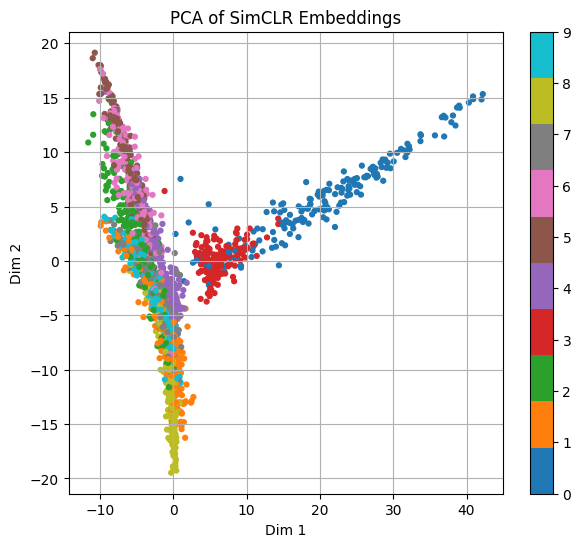

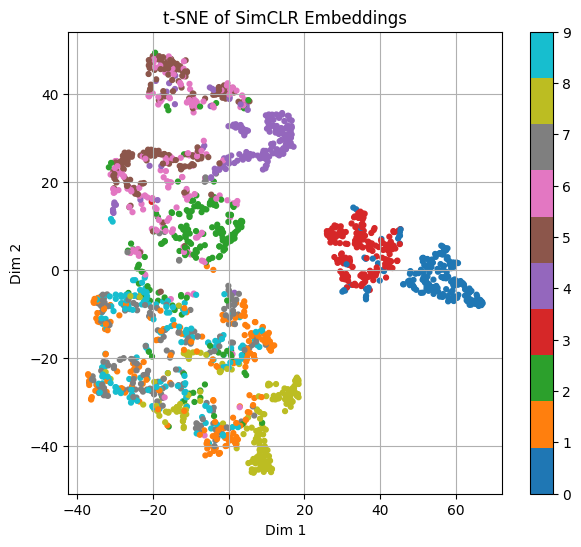

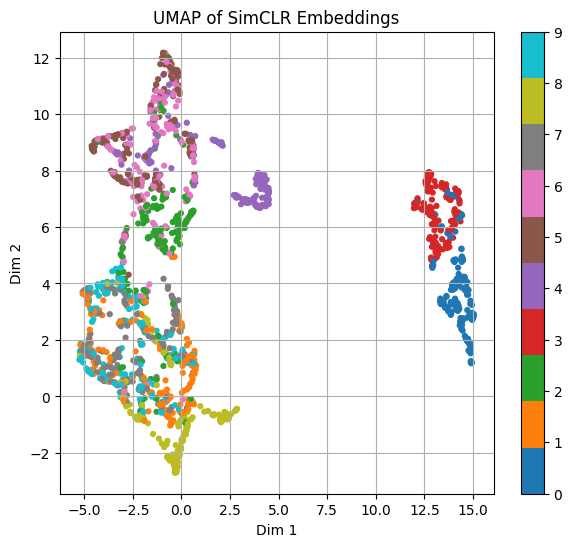

In [29]:
all_features = np.concatenate([train_features, test_features], axis=0)
all_labels = np.concatenate([train_labels, test_labels], axis=0)

MAX_POINTS = 3000
if len(all_features) > MAX_POINTS:
    idx = np.random.choice(len(all_features), MAX_POINTS, replace=False)
    vis_features = all_features[idx]
    vis_labels = all_labels[idx]
else:
    vis_features = all_features
    vis_labels = all_labels

pca = PCA(n_components=2, random_state=42)
pca_2d = pca.fit_transform(vis_features)

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca")
tsne_2d = tsne.fit_transform(vis_features)

umap_model = umap.UMAP(n_components=2, random_state=42)
umap_2d = umap_model.fit_transform(vis_features)

sil_pca = silhouette_score(pca_2d, vis_labels)
sil_tsne = silhouette_score(tsne_2d, vis_labels)
sil_umap = silhouette_score(umap_2d, vis_labels)

print("Silhouette Score (PCA):", sil_pca)
print("Silhouette Score (t-SNE):", sil_tsne)
print("Silhouette Score (UMAP):", sil_umap)

def plot_2d_embedding(emb, labels, title):
    plt.figure(figsize=(7,6))
    scatter = plt.scatter(emb[:,0], emb[:,1], c=labels, cmap="tab10", s=12)
    plt.title(title)
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.colorbar(scatter)
    plt.grid(True)
    plt.show()

plot_2d_embedding(pca_2d, vis_labels, "PCA of SimCLR Embeddings")
plot_2d_embedding(tsne_2d, vis_labels, "t-SNE of SimCLR Embeddings")
plot_2d_embedding(umap_2d, vis_labels, "UMAP of SimCLR Embeddings")

**ROC curves for linear probe**

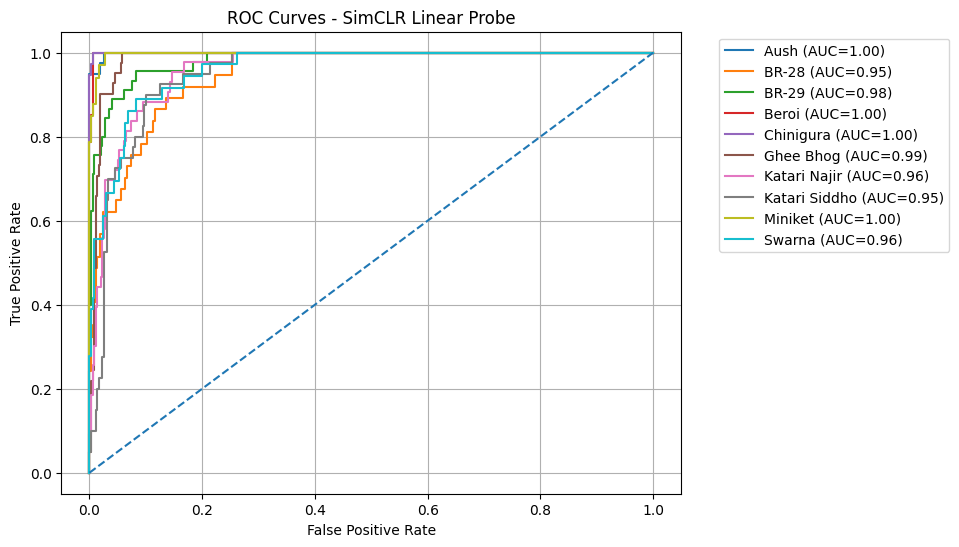

In [30]:
probs_lp = linear_results["probs"]
labels_lp = linear_results["labels"]

y_true_bin = label_binarize(labels_lp, classes=list(range(NUM_CLASSES)))

plt.figure(figsize=(8,6))
for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], probs_lp[:, i])
    roc_auc_i = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc_i:.2f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - SimCLR Linear Probe")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()

**GFLOPs**

In [31]:
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)

macs_lp, params_lp = profile(linear_probe, inputs=(dummy_input,), verbose=False)
gflops_lp = macs_lp / 1e9
print("Linear Probe GFLOPs:", gflops_lp)

macs_ft, params_ft = profile(finetune_model, inputs=(dummy_input,), verbose=False)
gflops_ft = macs_ft / 1e9
print("Fine-Tune GFLOPs:", gflops_ft)

Linear Probe GFLOPs: 4.131715072
Fine-Tune GFLOPs: 4.131715072


**Label-efficiency curve**

In [32]:
def build_subset_loader(dataset, fraction, batch_size=32, shuffle=True):
    n = len(dataset)
    subset_size = max(1, int(n * fraction))
    indices = np.random.RandomState(42).choice(n, subset_size, replace=False)
    subset = Subset(dataset, indices)
    loader = DataLoader(subset, batch_size=batch_size, shuffle=shuffle, num_workers=2, pin_memory=True)
    return loader, subset_size

label_eff_results = []

fractions = [0.01, 0.05, 0.10, 0.25, 0.50]

for frac in fractions:
    subset_loader, subset_size = build_subset_loader(train_ds_eval, frac, batch_size=BATCH_SIZE, shuffle=True)

    temp_probe = SimCLRLinearProbe(simclr_model, BACKBONE_NAME, NUM_CLASSES).to(DEVICE)

    temp_probe, temp_hist, temp_time = train_torch_classifier(
        temp_probe,
        subset_loader,
        val_loader_eval,
        epochs=10,
        lr=LR_LINEAR
    )

    temp_res = evaluate_torch_model(temp_probe, test_loader_eval, class_names)

    label_eff_results.append({
        "fraction": frac,
        "subset_size": subset_size,
        "accuracy": temp_res["accuracy"]
    })

label_eff_df = pd.DataFrame(label_eff_results)
label_eff_df

/tmp/ipykernel_55/2095318593.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_MIXED_PRECISION)
/tmp/ipykernel_55/2095318593.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):
/tmp/ipykernel_55/2095318593.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):


Epoch [1/10] Train Loss: 2.1357 | Val Loss: 1.7098 | Val Acc: 0.5437


/tmp/ipykernel_55/2095318593.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):
/tmp/ipykernel_55/2095318593.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):


Epoch [2/10] Train Loss: 1.2877 | Val Loss: 1.4589 | Val Acc: 0.7188


/tmp/ipykernel_55/2095318593.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):
/tmp/ipykernel_55/2095318593.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):


...

/tmp/ipykernel_55/2095318593.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):
/tmp/ipykernel_55/2095318593.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):


Epoch [9/10] Train Loss: 0.0272 | Val Loss: 0.0958 | Val Acc: 0.9750


/tmp/ipykernel_55/2095318593.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):
/tmp/ipykernel_55/2095318593.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):


Epoch [10/10] Train Loss: 0.0139 | Val Loss: 0.0951 | Val Acc: 0.9750

=== TEST RESULTS ===
Accuracy : 0.9625
Precision: 0.9634270975188493
Recall   : 0.9625
F1-score : 0.9623998019012955
ROC-AUC  : 0.9984091564763266
Test Time: 2.4617137908935547

=== PER-CLASS ACCURACY ===
Aush: 1.0000
BR-28: 0.8378
BR-29: 0.9556
Beroi: 1.0000
Chinigura: 1.0000
Ghee Bhog: 0.9512
Katari Najir: 0.9767
Katari Siddho: 0.9750
Miniket: 1.0000
Swarna: 0.9167

=== CONFUSION MATRIX ===
[[40  0  0  0  0  0  0  0  0  0]
 [ 0 31  0  0  0  0  0  5  0  1]
 [ 0  0 43  0  0  0  1  0  0  1]
 [ 0  0  0 47  0  0  0  0  0  0]
 [ 0  0  0  0 38  0  0  0  0  0]
 [ 0  0  0  0  0 39  2  0  0  0]
 [ 0  0  1  0  0  0 42  0  0  0]
 [ 0  0  0  0  0  0  1 39  0  0]
 [ 0  0  0  0  0  0  0  0 33  0]
 [ 0  3  0  0  0  0  0  0  0 33]]

=== CLASSIFICATION REPORT ===
               precision    recall  f1-score   support

         Aush       1.00      1.00      1.00        40
        BR-28       0.91      0.84      0.87        37
     

,fraction,subset_size,accuracy
0,0.01,14,0.7450
1,0.05,72,0.9475
2,0.10,144,0.9575
3,0.25,360,0.9550
4,0.50,720,0.9625


**Plot label-efficiency curve**

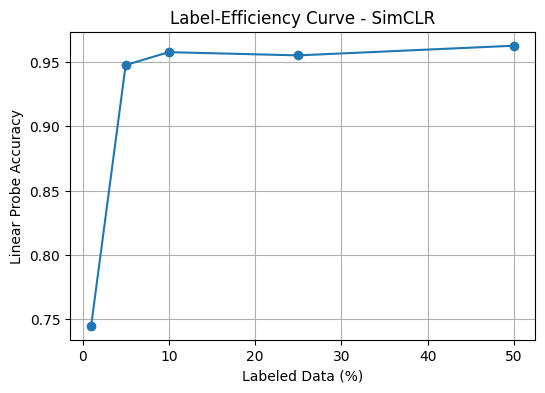

In [33]:
plt.figure(figsize=(6,4))
plt.plot(label_eff_df["fraction"] * 100, label_eff_df["accuracy"], marker="o")
plt.xlabel("Labeled Data (%)")
plt.ylabel("Linear Probe Accuracy")
plt.title("Label-Efficiency Curve - SimCLR")
plt.grid(True)
plt.show()

**Plot learning curves**

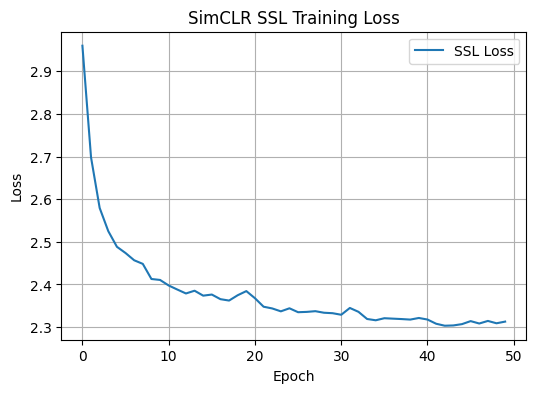

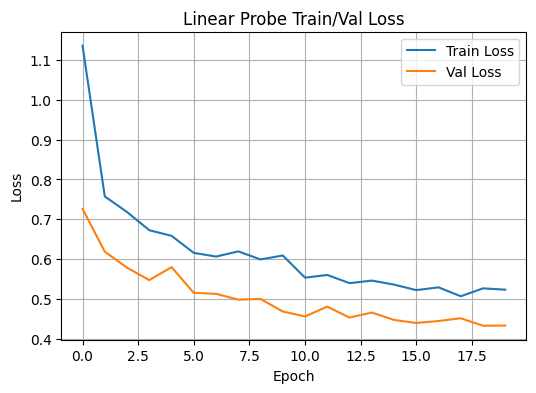

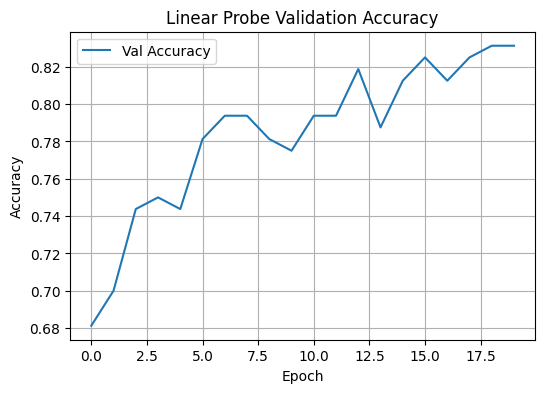

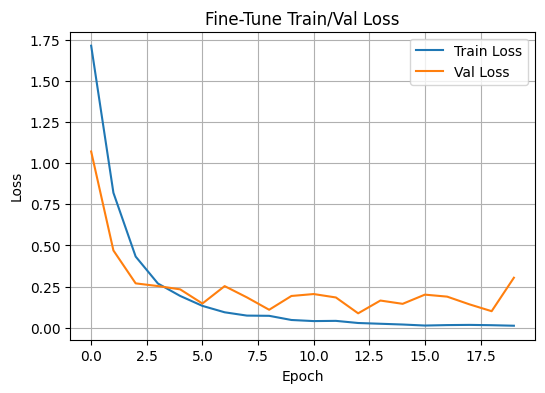

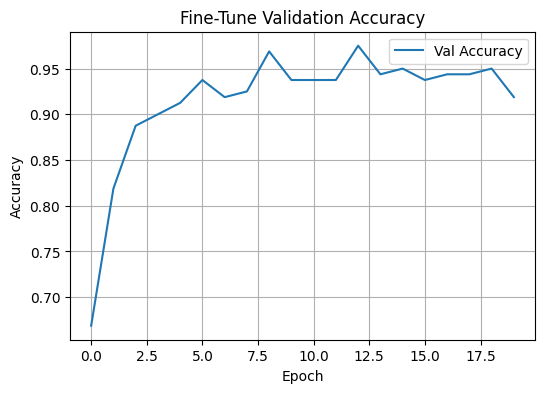

In [34]:
plt.figure(figsize=(6,4))
plt.plot(ssl_history["loss"], label="SSL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SimCLR SSL Training Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(linear_history["train_loss"], label="Train Loss")
plt.plot(linear_history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Linear Probe Train/Val Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(linear_history["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Linear Probe Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(finetune_history["train_loss"], label="Train Loss")
plt.plot(finetune_history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Fine-Tune Train/Val Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(finetune_history["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Fine-Tune Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

**Final comparison table**

In [35]:
comparison_rows = []

comparison_rows.append({
    "Method": "Linear Probe",
    "Accuracy": linear_results["accuracy"],
    "Precision": linear_results["precision"],
    "Recall": linear_results["recall"],
    "F1": linear_results["f1"],
    "ROC_AUC": linear_results["roc_auc"],
    "Train_Time_sec": linear_train_time,
    "Test_Time_sec": linear_results["test_time_sec"],
    "GFLOPs": gflops_lp
})

comparison_rows.append({
    "Method": "Full Fine-Tune",
    "Accuracy": finetune_results["accuracy"],
    "Precision": finetune_results["precision"],
    "Recall": finetune_results["recall"],
    "F1": finetune_results["f1"],
    "ROC_AUC": finetune_results["roc_auc"],
    "Train_Time_sec": finetune_train_time,
    "Test_Time_sec": finetune_results["test_time_sec"],
    "GFLOPs": gflops_ft
})

for r in shallow_results:
    comparison_rows.append({
        "Method": r["model"],
        "Accuracy": r["accuracy"],
        "Precision": r["precision"],
        "Recall": r["recall"],
        "F1": r["f1"],
        "ROC_AUC": r["roc_auc"],
        "Train_Time_sec": r["train_time_sec"],
        "Test_Time_sec": None,
        "GFLOPs": None
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,Method,Accuracy,Precision,Recall,F1,ROC_AUC,Train_Time_sec,Test_Time_sec,GFLOPs
0,Linear Probe,0.7875,0.788474,0.7875,0.785066,0.978260,182.679171,3.542662,4.131715
1,Full Fine-Tune,0.9675,0.967775,0.9675,0.967326,0.998997,199.827365,2.743449,4.131715
2,MLP Head,0.8050,0.808143,0.8050,0.804761,0.980076,7.454555,NaN,NaN
3,SVM Head,0.7850,0.790084,0.7850,0.784395,0.976488,4.932432,NaN,NaN
4,Decision Tree Head,0.6975,0.691887,0.6975,0.693369,0.831797,0.687636,NaN,NaN
5,Random Forest Head,0.7975,0.794055,0.7975,0.794900,0.980322,1.098758,NaN,NaN


**Save Outputs**

In [36]:
comparison_df.to_csv("/kaggle/working/simclr_comparison_table.csv", index=False)
label_eff_df.to_csv("/kaggle/working/simclr_label_efficiency.csv", index=False)
pd.DataFrame(knn_results).to_csv("/kaggle/working/simclr_knn_results.csv", index=False)

torch.save(simclr_model.state_dict(), "/kaggle/working/simclr_ssl_model.pth")
torch.save(linear_probe.state_dict(), "/kaggle/working/simclr_linear_probe.pth")
torch.save(finetune_model.state_dict(), "/kaggle/working/simclr_finetune_model.pth")

print("Saved files:")
print("/kaggle/working/simclr_comparison_table.csv")
print("/kaggle/working/simclr_label_efficiency.csv")
print("/kaggle/working/simclr_knn_results.csv")
print("/kaggle/working/simclr_ssl_model.pth")
print("/kaggle/working/simclr_linear_probe.pth")
print("/kaggle/working/simclr_finetune_model.pth")

Saved files:
/kaggle/working/simclr_comparison_table.csv
/kaggle/working/simclr_label_efficiency.csv
/kaggle/working/simclr_knn_results.csv
/kaggle/working/simclr_ssl_model.pth
/kaggle/working/simclr_linear_probe.pth
/kaggle/working/simclr_finetune_model.pth
